# Shanghai Disneyland Attendance Data Cleaning and Analysis

## Notebook Goals

In the previous notebook, we generated a historical attendance dataset for Shanghai Disney Resort. This notebook will cover:

1. **Data loading and initial inspection** - Understand the dataset structure and quality
2. **Data cleaning** - Handle missing values, outliers, and duplicates
3. **Exploratory Data Analysis (EDA)** - Understand the main patterns and characteristics of the data
4. **Feature correlation analysis** - Identify the key factors that influence attendance
5. **Data visualization** - Present the patterns visually
6. **Data preparation** - Prepare training data for machine-learning models

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# Ignore warnings
warnings.filterwarnings('ignore')

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

In [2]:
# Load data
df = pd.read_csv('data/raw/shanghai_disney_attendance.csv', parse_dates=['date'])

print(f"Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns.tolist()}")

Data loaded successfully!
Dataset shape: (3653, 22)

Dataset columns: ['date', 'year', 'month', 'day', 'weekday', 'weekday_name', 'is_weekend', 'is_holiday', 'holiday_name', 'holiday_multiplier', 'monthly_weight', 'weekday_weight', 'attendance', 'season', 'is_school_break', 'temperature', 'is_rainy', 'has_special_event', 'day_of_year', 'week_of_year', 'is_month_start', 'is_month_end']


In [3]:
# Preview the first rows
print("First 10 rows:")
df.head(10)

First 10 rows:


,date,year,month,day,weekday,weekday_name,is_weekend,is_holiday,holiday_name,holiday_multiplier,monthly_weight,weekday_weight,attendance,season,is_school_break,temperature,is_rainy,has_special_event,day_of_year,week_of_year,is_month_start,is_month_end
0,2016-01-01,2016,1,1,4,Friday,False,True,new_year,1.3,0.074503,1.086207,50426,winter,False,6.5,0,True,1,53,True,False
1,2016-01-02,2016,1,2,5,Saturday,True,True,new_year,1.3,0.074503,1.086207,51970,winter,False,4.6,0,True,2,53,True,False
2,2016-01-03,2016,1,3,6,Sunday,True,True,new_year,1.3,0.074503,0.945402,46473,winter,False,6.9,0,True,3,53,True,False
3,2016-01-04,2016,1,4,0,Monday,False,False,NaN,1.0,0.074503,1.066092,40976,winter,False,9.6,0,True,4,1,True,False
4,2016-01-05,2016,1,5,1,Tuesday,False,False,NaN,1.0,0.074503,0.965517,43595,winter,False,4.3,0,True,5,1,True,False
5,2016-01-06,2016,1,6,2,Wednesday,False,False,NaN,1.0,0.074503,0.885057,27689,winter,False,4.3,0,True,6,1,False,False
6,2016-01-07,2016,1,7,3,Thursday,False,False,NaN,1.0,0.074503,0.965517,36660,winter,False,9.7,1,True,7,1,False,False
7,2016-01-08,2016,1,8,4,Friday,False,False,NaN,1.0,0.074503,1.086207,31741,winter,False,7.3,0,True,8,1,False,False
8,2016-01-09,2016,1,9,5,Saturday,True,False,NaN,1.0,0.074503,1.086207,41014,winter,False,3.6,0,True,9,1,False,False
9,2016-01-10,2016,1,10,6,Sunday,True,False,NaN,1.0,0.074503,0.945402,38981,winter,False,6.6,0,True,10,1,False,False


In [4]:
# Check basic dataset information
print("Basic dataset information:")
df.info()

Basic dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                3653 non-null   datetime64[ns]
 1   year                3653 non-null   int64         
 2   month               3653 non-null   int64         
 3   day                 3653 non-null   int64         
 4   weekday             3653 non-null   int64         
 5   weekday_name        3653 non-null   object        
 6   is_weekend          3653 non-null   bool          
 7   is_holiday          3653 non-null   bool          
 8   holiday_name        310 non-null    object        
 9   holiday_multiplier  3653 non-null   float64       
 10  monthly_weight      3653 non-null   float64       
 11  weekday_weight      3653 non-null   float64       
 12  attendance          3653 non-null   int64         
 13  season              3

In [5]:
# View descriptive statistics
print("Descriptive statistics for numeric features:")
df.describe()

Descriptive statistics for numeric features:


,date,year,month,day,weekday,holiday_multiplier,monthly_weight,weekday_weight,attendance,temperature,is_rainy,day_of_year,week_of_year
count,3653,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,2020-12-31 00:00:00,2020.499589,6.522310,15.731454,3.000000,1.051465,0.083286,1.000009,73521.103750,17.215494,0.375855,183.150287,26.551601
min,2016-01-01 00:00:00,2016.000000,1.000000,1.000000,0.000000,1.000000,0.057947,0.885057,14957.000000,-4.000000,0.000000,1.000000,1.000000
25%,2018-07-02 00:00:00,2018.000000,4.000000,8.000000,1.000000,1.000000,0.064570,0.945402,45470.000000,9.200000,0.000000,92.000000,14.000000
50%,2020-12-31 00:00:00,2020.000000,7.000000,16.000000,3.000000,1.000000,0.074503,0.965517,66783.000000,16.900000,0.000000,183.000000,27.000000
75%,2023-07-02 00:00:00,2023.000000,10.000000,23.000000,5.000000,1.000000,0.100993,1.086207,95259.000000,25.100000,1.000000,274.000000,40.000000
max,2025-12-31 00:00:00,2025.000000,12.000000,31.000000,6.000000,1.900000,0.114238,1.086207,250923.000000,41.600000,1.000000,366.000000,53.000000
std,NaN,2.873056,3.449345,8.802064,2.000548,0.183316,0.019846,0.073505,37171.628782,9.195846,0.484409,105.467566,15.065333


## 3. Data Cleaning

Data cleaning is a key step in analysis and includes:
1. Checking and handling missing values
2. Checking and handling duplicate values
3. Checking and handling outliers
4. Data type conversion

In [6]:
# Check missing values
print("Missing value summary:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing ratio (%)': missing_pct})
print(missing_df[missing_df['Missing count'] > 0])

if missing.sum() == 0:
    print("\nThe dataset contains no missing values!")

Missing value summary:
              Missing count  Missing ratio (%)
holiday_name           3343              91.51


In [7]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Check duplicate dates
date_duplicates = df['date'].duplicated().sum()
print(f"Duplicate date count: {date_duplicates}")

Number of duplicate rows: 0
Duplicate date count: 0


In [8]:
# Check outliers - using the IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check attendance outliers
outliers, lower, upper = detect_outliers_iqr(df, 'attendance')
print(f"Attendance outlier detection (IQR method):")
print(f"  Lower bound: {lower:,.0f}")
print(f"  Upper bound: {upper:,.0f}")
print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# View outlier details
if len(outliers) > 0:
    print("\nOutlier examples:")
    print(outliers[['date', 'attendance', 'is_holiday', 'holiday_name']].head(10))

Attendance outlier detection (IQR method):
  Lower bound: -29,214
  Upper bound: 169,942
  Number of outliers: 64 (1.75%)

Outlier examples:
           date  attendance  is_holiday     holiday_name
771  2018-02-10      170086        True  spring_festival
851  2018-05-01      176357        True        labor_day
855  2018-05-05      170404        True        labor_day
892  2018-06-11      173623        True      dragon_boat
1142 2019-02-16      186080        True  spring_festival
1218 2019-05-03      192280        True        labor_day
1219 2019-05-04      185940        True        labor_day
2597 2023-02-10      206942        True  spring_festival
2600 2023-02-13      214649        True  spring_festival
2603 2023-02-16      177485        True  spring_festival


In [9]:
# Analyze outliers: these may be holiday peaks and can be normal
print("Outlier analysis:")
print(f"  Holiday outliers: {outliers['is_holiday'].sum()}")
print(f"  Non-holiday outliers: {(~outliers['is_holiday']).sum()}")

# Attendance spikes on holidays are expected and do not require adjustment
print("\nConclusion: most outliers come from holidays, which is expected and does not require treatment.")

Outlier analysis:
  Holiday outliers: 46
  Non-holiday outliers: 18

Conclusion: most outliers come from holidays, which is expected and does not require treatment.


In [10]:
# Check and convert data types
print("Data types:")
print(df.dtypes)

# Convert boolean fields
bool_columns = ['is_weekend', 'is_holiday', 'is_school_break', 'is_rainy', 'has_special_event', 'is_month_start', 'is_month_end']
for col in bool_columns:
    if col in df.columns:
        df[col] = df[col].astype(bool)

print("\nData type conversion completed!")

Data types:
date                  datetime64[ns]
year                           int64
month                          int64
day                            int64
weekday                        int64
weekday_name                  object
is_weekend                      bool
is_holiday                      bool
holiday_name                  object
holiday_multiplier           float64
monthly_weight               float64
weekday_weight               float64
attendance                     int64
season                        object
is_school_break                 bool
temperature                  float64
is_rainy                       int64
has_special_event               bool
day_of_year                    int64
week_of_year                   int64
is_month_start                  bool
is_month_end                    bool
dtype: object

Data type conversion completed!


## 4. Exploratory Data Analysis (EDA)

### 4.1 Overall attendance distribution

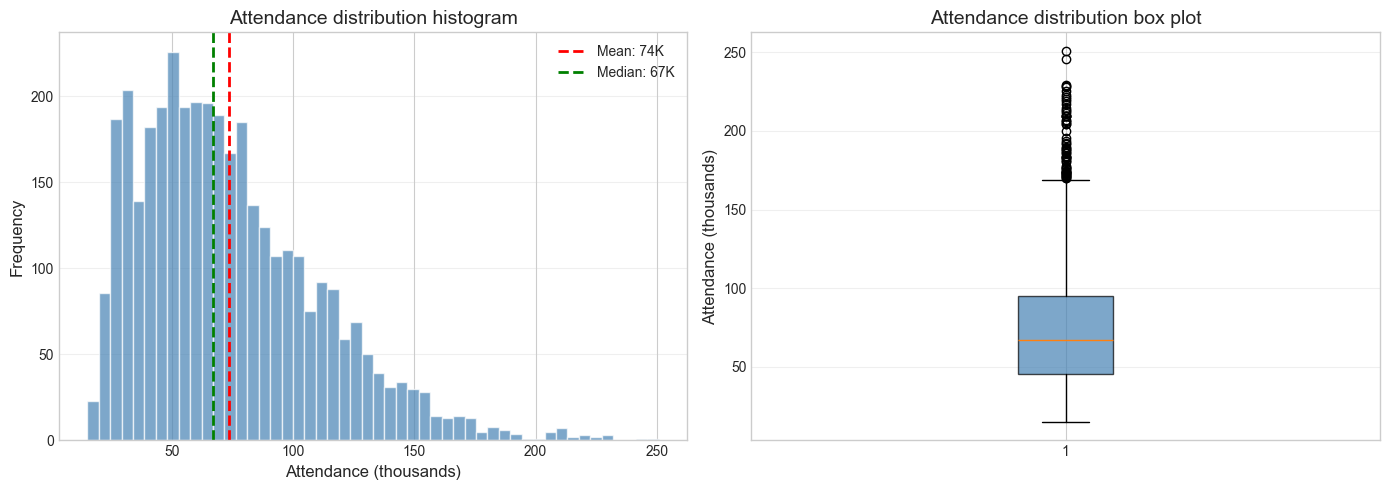


Chart saved as images/eda_attendance_distribution.png


In [11]:
# Attendance distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(df['attendance'] / 1000, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax1.axvline(df['attendance'].mean() / 1000, color='red', linestyle='--', linewidth=2, label=f'Mean: {df["attendance"].mean()/1000:.0f}K')
ax1.axvline(df['attendance'].median() / 1000, color='green', linestyle='--', linewidth=2, label=f'Median: {df["attendance"].median()/1000:.0f}K')
ax1.set_xlabel('Attendance (thousands)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Attendance distribution histogram', fontsize=14)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2 = axes[1]
bp = ax2.boxplot(df['attendance'] / 1000, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)
ax2.set_ylabel('Attendance (thousands)', fontsize=12)
ax2.set_title('Attendance distribution box plot', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/eda_attendance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/eda_attendance_distribution.png")

### 4.2 Time trend analysis

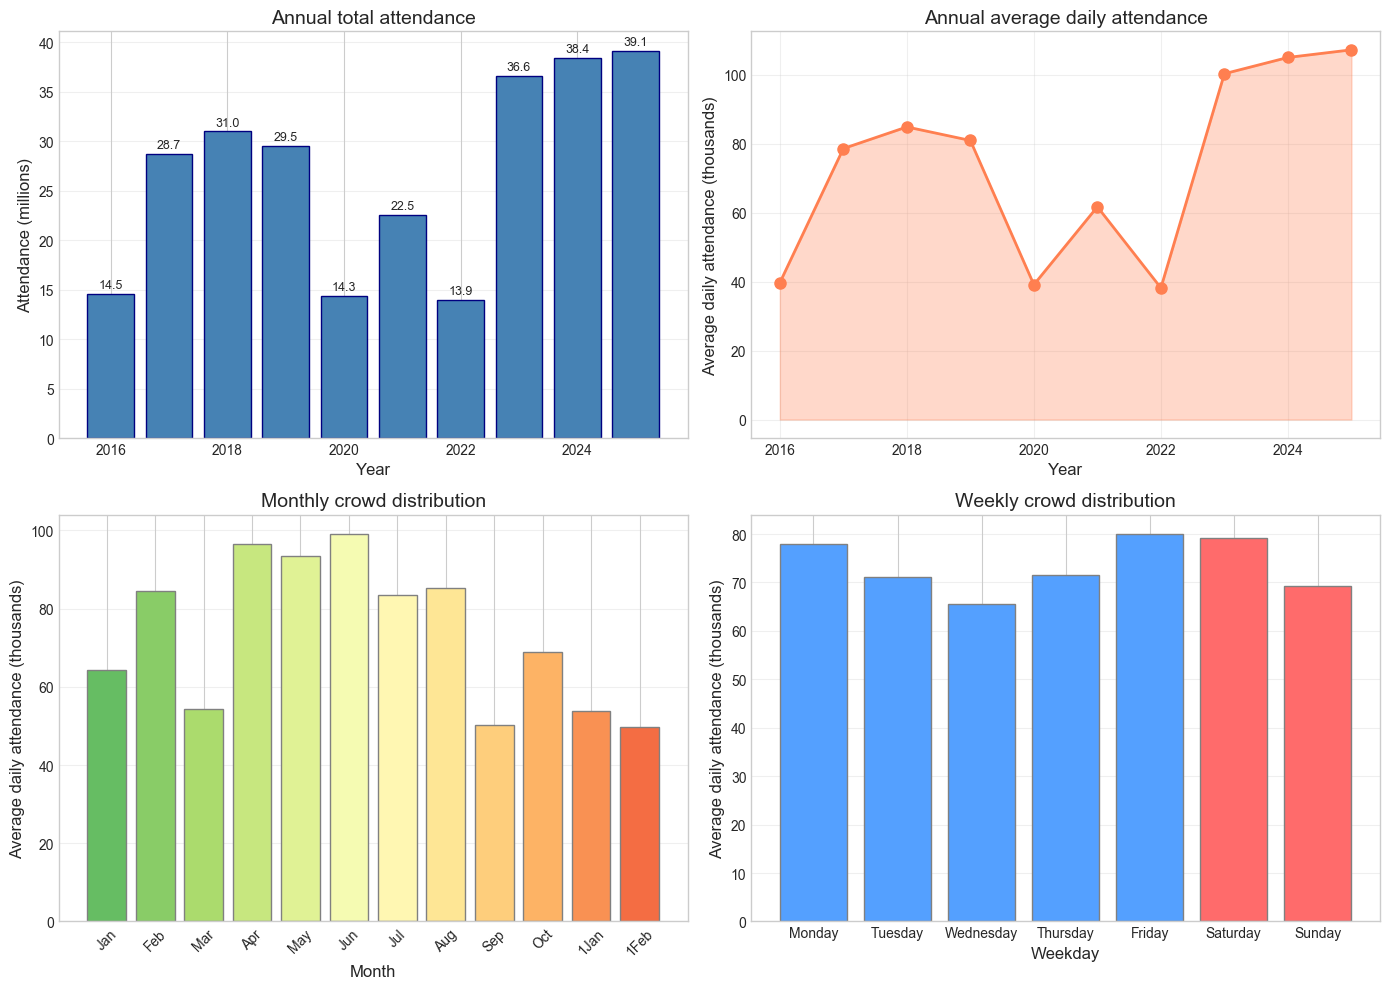


Chart saved as images/eda_time_trends.png


In [12]:
# Annual attendance trend
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Annual total attendance
ax1 = axes[0, 0]
yearly_total = df.groupby('year')['attendance'].sum() / 1_000_000
bars = ax1.bar(yearly_total.index, yearly_total.values, color='steelblue', edgecolor='navy')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Attendance (millions)', fontsize=12)
ax1.set_title('Annual total attendance', fontsize=14)
ax1.grid(axis='y', alpha=0.3)
# Add value labels
for bar, val in zip(bars, yearly_total.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Annual average daily attendance
ax2 = axes[0, 1]
yearly_avg = df.groupby('year')['attendance'].mean() / 1000
ax2.plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2, markersize=8, color='coral')
ax2.fill_between(yearly_avg.index, yearly_avg.values, alpha=0.3, color='coral')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Average daily attendance (thousands)', fontsize=12)
ax2.set_title('Annual average daily attendance', fontsize=14)
ax2.grid(True, alpha=0.3)

# Monthly crowd distribution
ax3 = axes[1, 0]
monthly_avg = df.groupby('month')['attendance'].mean() / 1000
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', '1Jan', '1Feb']
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 12))
bars = ax3.bar(month_names, monthly_avg.values, color=colors, edgecolor='gray')
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Average daily attendance (thousands)', fontsize=12)
ax3.set_title('Monthly crowd distribution', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Weekly crowd distribution
ax4 = axes[1, 1]
weekday_avg = df.groupby('weekday')['attendance'].mean() / 1000
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = ['#54a0ff' if i < 5 else '#ff6b6b' for i in range(7)]
bars = ax4.bar(weekday_names, weekday_avg.values, color=colors, edgecolor='gray')
ax4.set_xlabel('Weekday', fontsize=12)
ax4.set_ylabel('Average daily attendance (thousands)', fontsize=12)
ax4.set_title('Weekly crowd distribution', fontsize=14)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/eda_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/eda_time_trends.png")

### 4.3 Holiday impact analysis

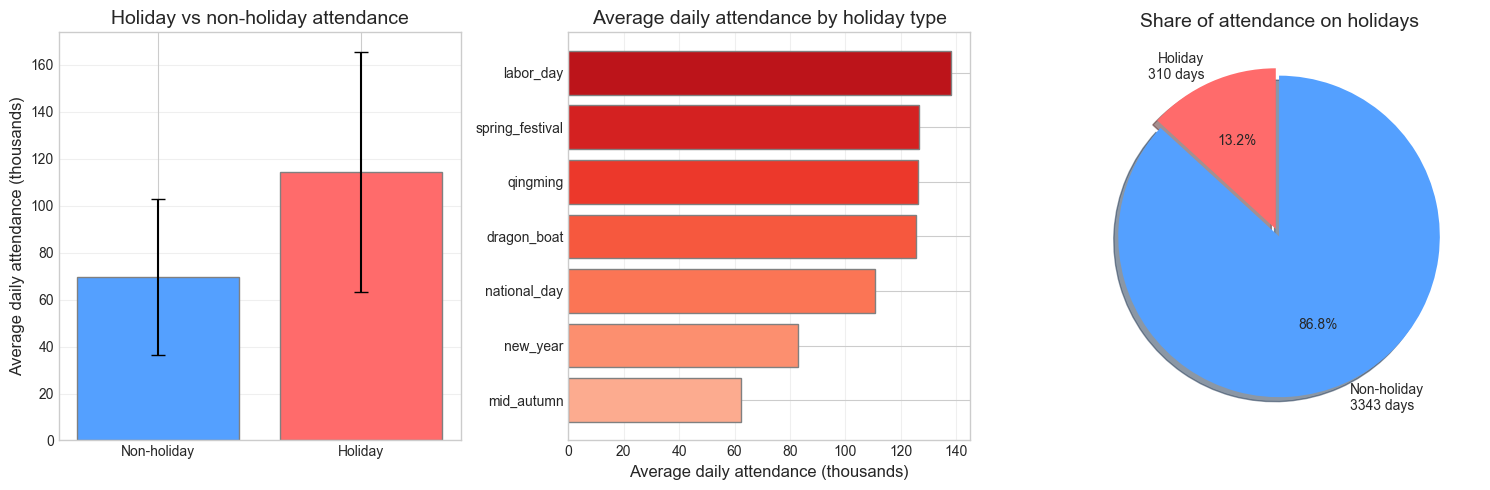


Chart saved as images/eda_holiday_impact.png


In [13]:
# Holiday impact analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Holiday vs Non-holiday
ax1 = axes[0]
holiday_stats = df.groupby('is_holiday')['attendance'].agg(['mean', 'std']) / 1000
labels = ['Non-holiday', 'Holiday']
x = np.arange(len(labels))
bars = ax1.bar(x, holiday_stats['mean'], yerr=holiday_stats['std'], capsize=5, color=['#54a0ff', '#ff6b6b'], edgecolor='gray')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Average daily attendance (thousands)', fontsize=12)
ax1.set_title('Holiday vs non-holiday attendance', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# Attendance by holiday type
ax2 = axes[1]
holiday_data = df[df['is_holiday'] == True].groupby('holiday_name')['attendance'].mean() / 1000
holiday_data = holiday_data.sort_values(ascending=True)
colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(holiday_data)))
bars = ax2.barh(holiday_data.index, holiday_data.values, color=colors, edgecolor='gray')
ax2.set_xlabel('Average daily attendance (thousands)', fontsize=12)
ax2.set_title('Average daily attendance by holiday type', fontsize=14)
ax2.grid(axis='x', alpha=0.3)

# Share of attendance on holidays
ax3 = axes[2]
holiday_count = df[df['is_holiday'] == True].shape[0]
non_holiday_count = df[df['is_holiday'] == False].shape[0]
holiday_attendance = df[df['is_holiday'] == True]['attendance'].sum()
non_holiday_attendance = df[df['is_holiday'] == False]['attendance'].sum()

sizes = [holiday_attendance, non_holiday_attendance]
labels_pie = [f'Holiday\n{holiday_count} days', f'Non-holiday\n{non_holiday_count} days']
colors_pie = ['#ff6b6b', '#54a0ff']
explode = (0.05, 0)
ax3.pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%', shadow=True, startangle=90)
ax3.set_title('Share of attendance on holidays', fontsize=14)

plt.tight_layout()
plt.savefig('images/eda_holiday_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/eda_holiday_impact.png")

### 4.4 Seasonality analysis

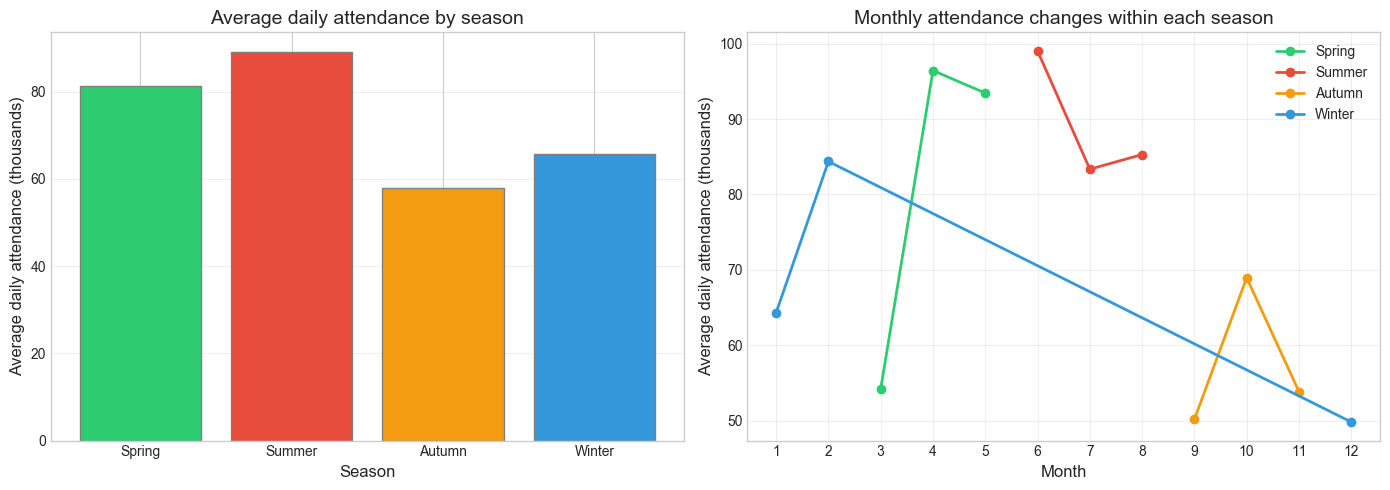


Chart saved as images/eda_seasonal.png


In [14]:
# Seasonality analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SeasonAttendance distribution
ax1 = axes[0]
season_order = ['spring', 'summer', 'autumn', 'winter']
season_names = {'spring': 'Spring', 'summer': 'Summer', 'autumn': 'Autumn', 'winter': 'Winter'}
season_colors = {'spring': '#2ecc71', 'summer': '#e74c3c', 'autumn': '#f39c12', 'winter': '#3498db'}

season_data = df.groupby('season')['attendance'].mean() / 1000
season_data = season_data.reindex(season_order)
colors = [season_colors[s] for s in season_order]
bars = ax1.bar([season_names[s] for s in season_order], season_data.values, color=colors, edgecolor='gray')
ax1.set_xlabel('Season', fontsize=12)
ax1.set_ylabel('Average daily attendance (thousands)', fontsize=12)
ax1.set_title('Average daily attendance by season', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# Monthly changes within each season
ax2 = axes[1]
for season in season_order:
    months = {'spring': [3, 4, 5], 'summer': [6, 7, 8], 'autumn': [9, 10, 11], 'winter': [12, 1, 2]}
    season_df = df[df['month'].isin(months[season])]
    monthly_avg = season_df.groupby('month')['attendance'].mean() / 1000
    ax2.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, label=season_names[season], color=season_colors[season])

ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Average daily attendance (thousands)', fontsize=12)
ax2.set_title('Monthly attendance changes within each season', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('images/eda_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/eda_seasonal.png")

### 4.5 Weather impact analysis

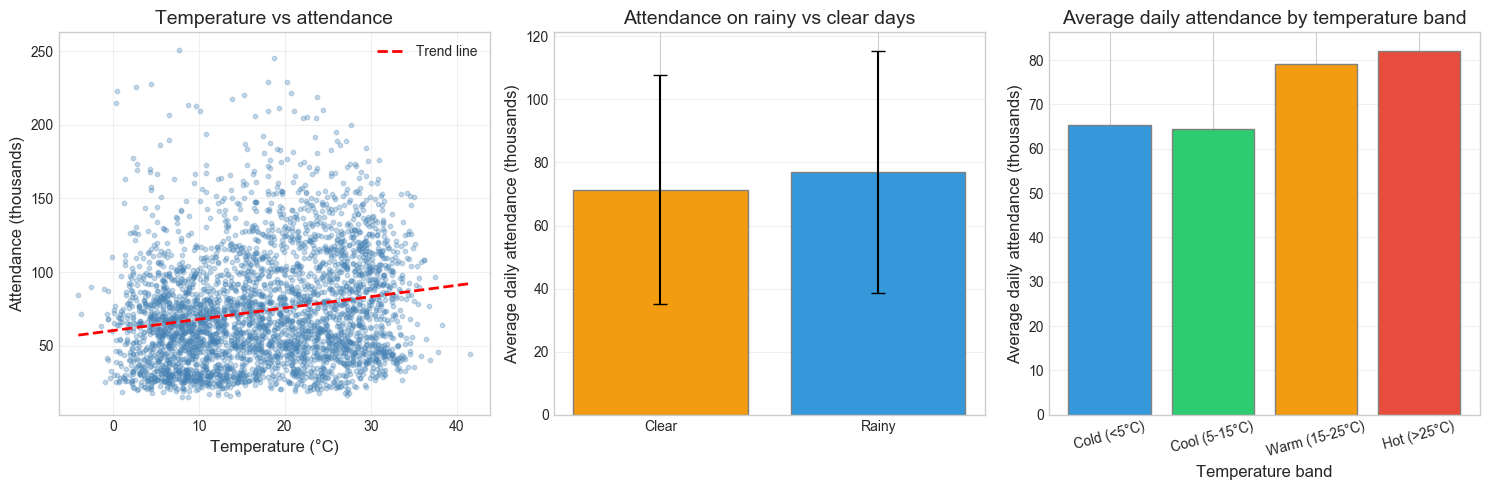


Chart saved as images/eda_weather_impact.png


In [15]:
# Weather impact analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Temperature vs attendance
ax1 = axes[0]
ax1.scatter(df['temperature'], df['attendance'] / 1000, alpha=0.3, c='steelblue', s=10)
# Add trend line
z = np.polyfit(df['temperature'], df['attendance'] / 1000, 1)
p = np.poly1d(z)
temp_range = np.linspace(df['temperature'].min(), df['temperature'].max(), 100)
ax1.plot(temp_range, p(temp_range), 'r--', linewidth=2, label='Trend line')
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Attendance (thousands)', fontsize=12)
ax1.set_title('Temperature vs attendance', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Rainy vs clear weather
ax2 = axes[1]
rain_stats = df.groupby('is_rainy')['attendance'].agg(['mean', 'std']) / 1000
labels = ['Clear', 'Rainy']
x = np.arange(len(labels))
bars = ax2.bar(x, rain_stats['mean'], yerr=rain_stats['std'], capsize=5, color=['#f39c12', '#3498db'], edgecolor='gray')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Average daily attendance (thousands)', fontsize=12)
ax2.set_title('Attendance on rainy vs clear days', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Attendance by temperature band
ax3 = axes[2]
df['temp_bin'] = pd.cut(df['temperature'], bins=[-5, 5, 15, 25, 35], labels=['Cold (<5°C)', 'Cool (5-15°C)', 'Warm (15-25°C)', 'Hot (>25°C)'])
temp_bin_avg = df.groupby('temp_bin')['attendance'].mean() / 1000
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = ax3.bar(temp_bin_avg.index, temp_bin_avg.values, color=colors, edgecolor='gray')
ax3.set_xlabel('Temperature band', fontsize=12)
ax3.set_ylabel('Average daily attendance (thousands)', fontsize=12)
ax3.set_title('Average daily attendance by temperature band', fontsize=14)
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/eda_weather_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/eda_weather_impact.png")

## 5. Feature correlation analysis

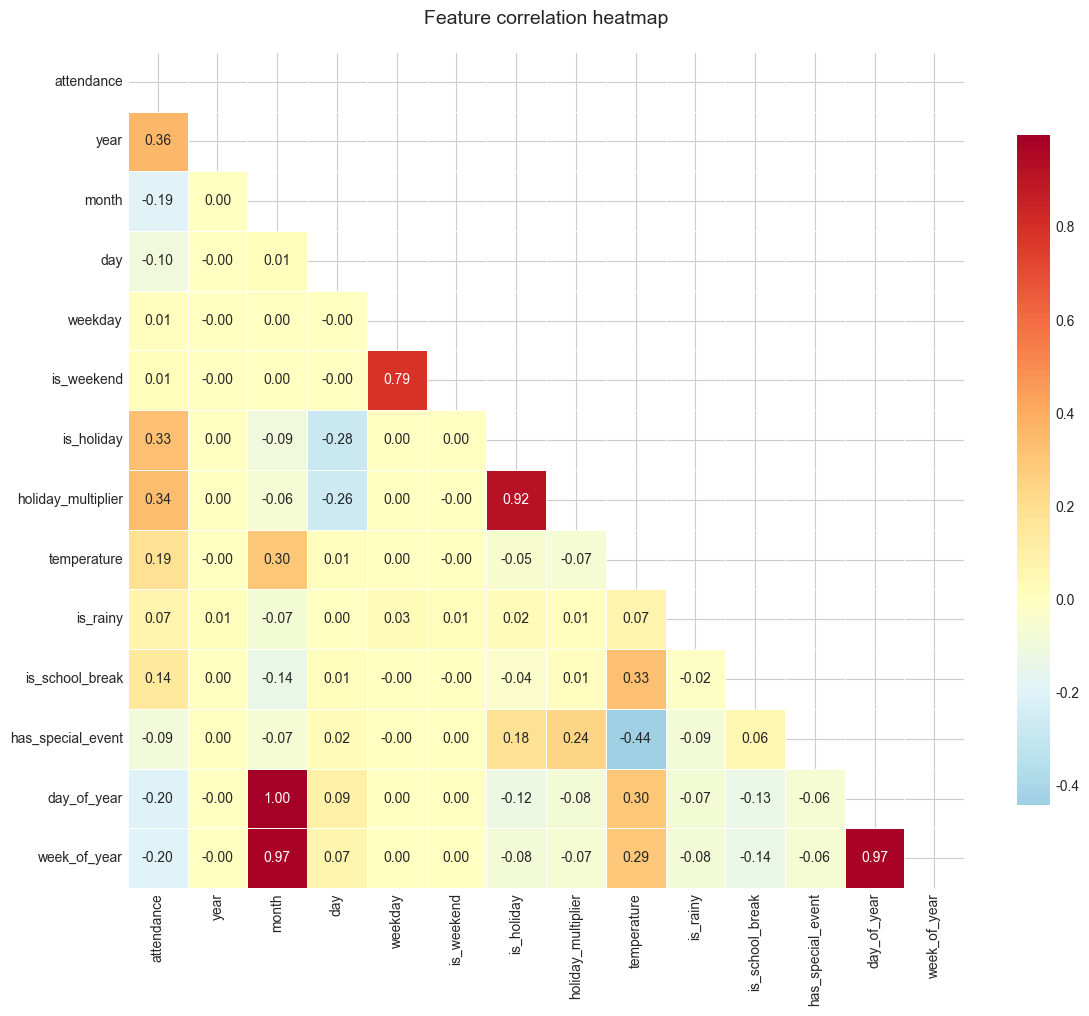


Chart saved as images/eda_correlation_heatmap.png


In [16]:
# Prepare numeric features
numeric_features = ['attendance', 'year', 'month', 'day', 'weekday', 'is_weekend', 
                    'is_holiday', 'holiday_multiplier', 'temperature', 'is_rainy', 
                    'is_school_break', 'has_special_event', 'day_of_year', 'week_of_year']

df_numeric = df[numeric_features].copy()

# Calculate correlation coefficients
correlation_matrix = df_numeric.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation heatmap', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('images/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/eda_correlation_heatmap.png")

Correlation with attendance (sorted by absolute value):
  year: 0.358
  holiday_multiplier: 0.335
  is_holiday: 0.334
  day_of_year: -0.201
  week_of_year: -0.197
  month: -0.192
  temperature: 0.190
  is_school_break: 0.143
  day: -0.098
  has_special_event: -0.087
  is_rainy: 0.074
  is_weekend: 0.012
  weekday: 0.008


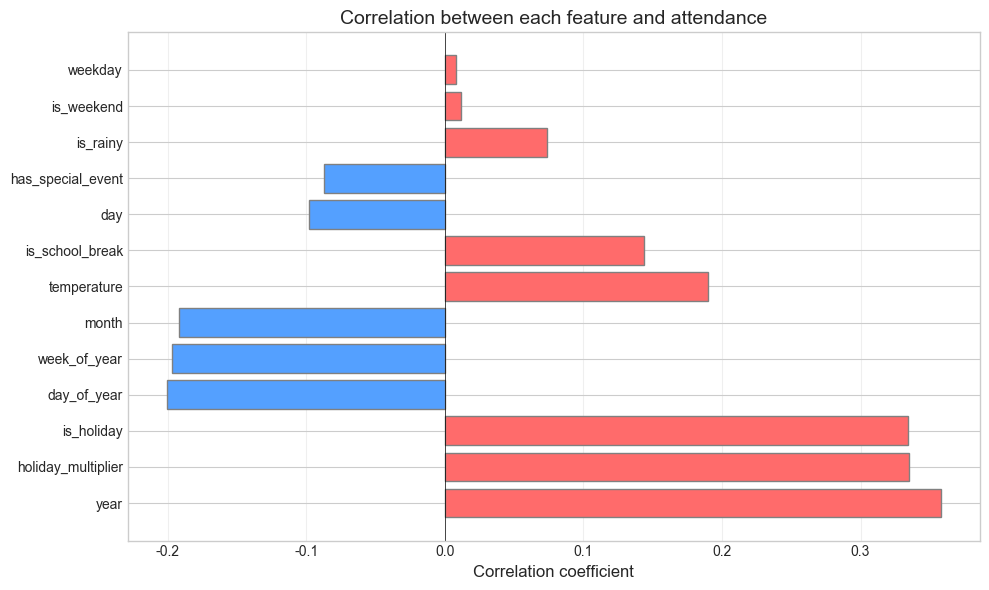


Chart saved as images/eda_attendance_correlation.png


In [17]:
# Rank correlations with attendance
attendance_corr = correlation_matrix['attendance'].drop('attendance').sort_values(key=abs, ascending=False)

print("Correlation with attendance (sorted by absolute value):")
for feature, corr in attendance_corr.items():
    print(f"  {feature}: {corr:.3f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b' if c > 0 else '#54a0ff' for c in attendance_corr.values]
bars = ax.barh(attendance_corr.index, attendance_corr.values, color=colors, edgecolor='gray')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation coefficient', fontsize=12)
ax.set_title('Correlation between each feature and attendance', fontsize=14)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('images/eda_attendance_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as images/eda_attendance_correlation.png")

## 6. Feature engineering

Based on the EDA results, we perform feature engineering to create more predictive features.

In [18]:
def feature_engineering(df):
    """
    Feature engineering: create new features
    """
    df = df.copy()
    
    # 1. Cyclical features using sine/cosine transforms
    # Month cycle
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Weekday cycle
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)
    
    # Day-of-year cycle
    df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
    
    # 2. Interaction features
    # Weekend+Holiday
    df['weekend_or_holiday'] = (df['is_weekend'] | df['is_holiday']).astype(int)
    
    # Summer break + weekend
    df['summer_weekend'] = ((df['is_school_break'] == True) & (df['is_weekend'] == True)).astype(int)
    
    # 3. Lag features (requires sorting by date)
    df = df.sort_values('date').reset_index(drop=True)
    
    # Previous-day attendance
    df['attendance_lag1'] = df['attendance'].shift(1)
    
    # Attendance on the same weekday one week earlier
    df['attendance_lag7'] = df['attendance'].shift(7)
    
    # Rolling mean attendance over the previous month
    df['attendance_rolling_30'] = df['attendance'].rolling(window=30, min_periods=1).mean()
    
    # 4. Categorical feature encoding
    # Season encoding
    season_map = {'spring': 0, 'summer': 1, 'autumn': 2, 'winter': 3}
    df['season_encoded'] = df['season'].map(season_map)
    
    # 5. Fill missing values in lag features
    df['attendance_lag1'] = df['attendance_lag1'].fillna(df['attendance'].mean())
    df['attendance_lag7'] = df['attendance_lag7'].fillna(df['attendance'].mean())
    
    return df

# Apply feature engineering
df_featured = feature_engineering(df)

print("Feature engineering completed!")
print(f"\nDataset shape after adding features: {df_featured.shape}")
print(f"\nAdded feature columns: {[col for col in df_featured.columns if col not in df.columns]}")

Feature engineering completed!

Dataset shape after adding features: (3653, 35)

Added feature columns: ['month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'day_of_year_sin', 'day_of_year_cos', 'weekend_or_holiday', 'summer_weekend', 'attendance_lag1', 'attendance_lag7', 'attendance_rolling_30', 'season_encoded']


In [19]:
# View the dataset after feature engineering
print("First rows after feature engineering:")
df_featured.head()

First rows after feature engineering:


,date,year,month,day,weekday,weekday_name,is_weekend,is_holiday,holiday_name,holiday_multiplier,monthly_weight,weekday_weight,attendance,season,is_school_break,temperature,is_rainy,has_special_event,day_of_year,week_of_year,is_month_start,is_month_end,temp_bin,month_sin,month_cos,weekday_sin,weekday_cos,day_of_year_sin,day_of_year_cos,weekend_or_holiday,summer_weekend,attendance_lag1,attendance_lag7,attendance_rolling_30,season_encoded
0,2016-01-01,2016,1,1,4,Friday,False,True,new_year,1.3,0.074503,1.086207,50426,winter,False,6.5,False,True,1,53,True,False,Cool (5-15°C),0.5,0.866025,-0.433884,-0.900969,0.017213,0.999852,1,0,73521.10375,73521.10375,50426.00,3
1,2016-01-02,2016,1,2,5,Saturday,True,True,new_year,1.3,0.074503,1.086207,51970,winter,False,4.6,False,True,2,53,True,False,Cold (<5°C),0.5,0.866025,-0.974928,-0.222521,0.034422,0.999407,1,0,50426.00000,73521.10375,51198.00,3
2,2016-01-03,2016,1,3,6,Sunday,True,True,new_year,1.3,0.074503,0.945402,46473,winter,False,6.9,False,True,3,53,True,False,Cool (5-15°C),0.5,0.866025,-0.781831,0.623490,0.051620,0.998667,1,0,51970.00000,73521.10375,49623.00,3
3,2016-01-04,2016,1,4,0,Monday,False,False,NaN,1.0,0.074503,1.066092,40976,winter,False,9.6,False,True,4,1,True,False,Cool (5-15°C),0.5,0.866025,0.000000,1.000000,0.068802,0.997630,0,0,46473.00000,73521.10375,47461.25,3
4,2016-01-05,2016,1,5,1,Tuesday,False,False,NaN,1.0,0.074503,0.965517,43595,winter,False,4.3,False,True,5,1,True,False,Cold (<5°C),0.5,0.866025,0.781831,0.623490,0.085965,0.996298,0,0,40976.00000,73521.10375,46688.00,3


## 7. Data preparation for model training

In [20]:
# Select features for model training
feature_columns = [
    # Time features
    'year', 'month', 'day', 'weekday',
    'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
    'day_of_year_sin', 'day_of_year_cos',
    # Boolean features
    'is_weekend', 'is_holiday', 'is_school_break', 'is_rainy', 'has_special_event',
    'weekend_or_holiday', 'summer_weekend',
    # Numeric features
    'holiday_multiplier', 'temperature',
    # Lag features
    'attendance_lag1', 'attendance_lag7', 'attendance_rolling_30',
    # Encoded features
    'season_encoded'
]

target_column = 'attendance'

# Prepare the feature matrix and target variable
X = df_featured[feature_columns]
y = df_featured[target_column]

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeatures used ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

Feature matrix shape: (3653, 23)
Target variable shape: (3653,)

Features used (23):
  1. year
  2. month
  3. day
  4. weekday
  5. month_sin
  6. month_cos
  7. weekday_sin
  8. weekday_cos
  9. day_of_year_sin
  10. day_of_year_cos
  11. is_weekend
  12. is_holiday
  13. is_school_break
  14. is_rainy
  15. has_special_event
  16. weekend_or_holiday
  17. summer_weekend
  18. holiday_multiplier
  19. temperature
  20. attendance_lag1
  21. attendance_lag7
  22. attendance_rolling_30
  23. season_encoded


In [21]:
# Split training and test sets by time
# Use data up to 2024 as the training set and 2025 as the test set
train_mask = df_featured['year'] < 2025
test_mask = df_featured['year'] >= 2025

X_train = X[train_mask]
y_train = y[train_mask]
X_test = X[test_mask]
y_test = y[test_mask]

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining date range: {df_featured[train_mask]['date'].min()} to {df_featured[train_mask]['date'].max()}")
print(f"Test date range: {df_featured[test_mask]['date'].min()} to {df_featured[test_mask]['date'].max()}")

Training set size: 3288 samples
Test set size: 365 samples

Training date range: 2016-01-01 00:00:00 to 2024-12-31 00:00:00
Test date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00


In [22]:
# Save processed data
df_featured.to_csv('data/processed/shanghai_disney_featured.csv', index=False, encoding='utf-8-sig')

# Save training and test datasets
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.to_csv('data/processed/train_data.csv', index=False)
test_data.to_csv('data/processed/test_data.csv', index=False)

print("Data saved:")
print("  - data/processed/shanghai_disney_featured.csv (full featured dataset)")
print("  - data/processed/train_data.csv (training set)")
print("  - data/processed/test_data.csv (test set)")

Data saved:
  - data/processed/shanghai_disney_featured.csv (full featured dataset)
  - data/processed/train_data.csv (training set)
  - data/processed/test_data.csv (test set)


## 8. Summary

### Data cleaning and analysis completed

This notebook completed the following tasks:

#### Data cleaning
1. Checked missing values: the dataset is complete
2. Checked duplicate values: no duplicates were found
3. Analyzed outliers: holiday peaks are expected
4. Completed data type conversion

#### Exploratory Data Analysis (EDA)
1. **Attendance distribution**：The distribution is right-skewed, with holiday peaks
2. **Time trends**：
   - Annual: attendance fell during 2020-2022 because of the pandemic and recovered after 2023
   - Monthly: April-August is the peak season, while September and February are relatively quieter
   - Weekly: weekends are busier than weekdays, and Wednesday is the quietest
3. **Holiday effect**：Holiday attendance is much higher than non-holiday attendance, with National Day having the strongest effect
4. **Seasonality**：Attendance is highest in summer and lowest in winter
5. **Weather impact**: attendance is positively associated with temperature, and rainy days are slightly quieter

#### Feature engineering
1. Created cyclical features using sine/cosine transforms
2. Created interaction features
3. Created lag features
4. Encoded categorical features

#### Data preparation
1. Selected 24 features for model training
2. Split the dataset by time into a training set (through 2024) and a test set (2025)
3. Saved the processed data

### Key findings

Main attendance drivers (ordered by importance):
1. **Holiday** - the most important factor
2. **Month/Season** - a clear seasonality pattern
3. **Weekday** - clear weekend effect
4. **Temperature** - warmer weather is associated with higher attendance
5. **Historical attendance** - shows temporal dependence

### Next Steps

In the next notebook, we will:
1. Select an appropriate machine-learning model
2. Train and tune the model
3. Evaluate model performance
4. Save the best model for the web application